In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import STL

In [9]:
name_path = 'New_York_Air_Quality.csv'
folder_path = 'dataset'

file_path = os.path.join(folder_path, name_path)

df = pd.read_csv(file_path) 
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head(5)

,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,AQI
0,2025-01-01 00:00:00+00:00,New York,304.0,49.6,8.2,17.0,10.0,11.8,26.375000
1,2025-01-01 01:00:00+00:00,New York,289.0,43.3,7.1,26.0,8.8,10.4,26.183334
2,2025-01-01 02:00:00+00:00,New York,269.0,34.5,5.6,38.0,7.4,8.8,25.924997
3,2025-01-01 03:00:00+00:00,New York,248.0,27.4,4.3,48.0,6.4,7.8,25.550000
4,2025-01-01 04:00:00+00:00,New York,224.0,23.4,3.5,54.0,6.0,7.4,25.066664


✅ Đã lấy cột 'PM2.5' từ dữ liệu gốc.


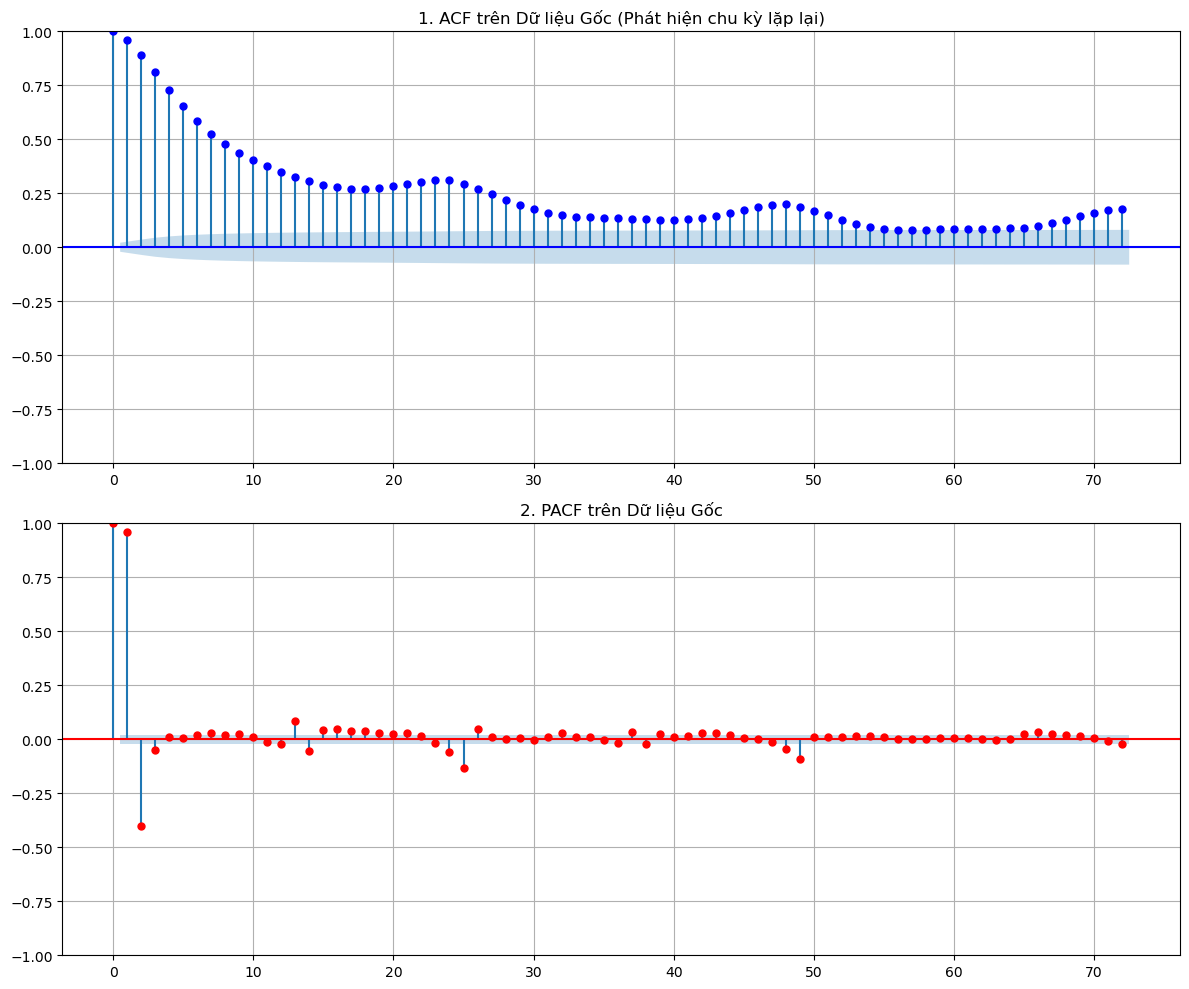

In [10]:

# ======================================================
# 1. CHUẨN BỊ DỮ LIỆU GỐC
# ======================================================
# Giả sử cột dữ liệu bạn cần phân tích tên là 'PM2.5'
# Nếu tên khác, bạn sửa lại trong dấu ngoặc vuông nhé
try:
    ts_original = df['PM2.5'] 
    print("✅ Đã lấy cột 'PM2.5' từ dữ liệu gốc.")
except KeyError:
    # Nếu không tìm thấy, thử lấy cột đầu tiên
    col_name = df.select_dtypes(include=['number']).columns[0]
    ts_original = df[col_name]
    print(f"⚠️ Không thấy 'PM2.5', đang dùng cột: {col_name}")

# ======================================================
# 2. VẼ BIỂU ĐỒ TỰ TƯƠNG QUAN (ACF & PACF)
# ======================================================
plt.figure(figsize=(12, 10))

# --- BIỂU ĐỒ 1: ACF (Autocorrelation) trên Dữ liệu gốc ---
# Mục tiêu: Tìm tính Mùa vụ (Seasonality) & Trend
# Lags=72: Nhìn lại 3 ngày (24 giờ * 3) để thấy rõ chu kỳ
ax1 = plt.subplot(2, 1, 1)
plot_acf(ts_original.dropna(), lags=72, ax=ax1, color='blue', title='1. ACF trên Dữ liệu Gốc (Phát hiện chu kỳ lặp lại)')
plt.grid(True)

# --- BIỂU ĐỒ 2: PACF (Partial Autocorrelation) trên Dữ liệu gốc ---
# Mục tiêu: Xem độ tác động trực tiếp
ax2 = plt.subplot(2, 1, 2)
plot_pacf(ts_original.dropna(), lags=72, ax=ax2, color='red', method='ywm', title='2. PACF trên Dữ liệu Gốc')
plt.grid(True)

plt.tight_layout()
plt.show()

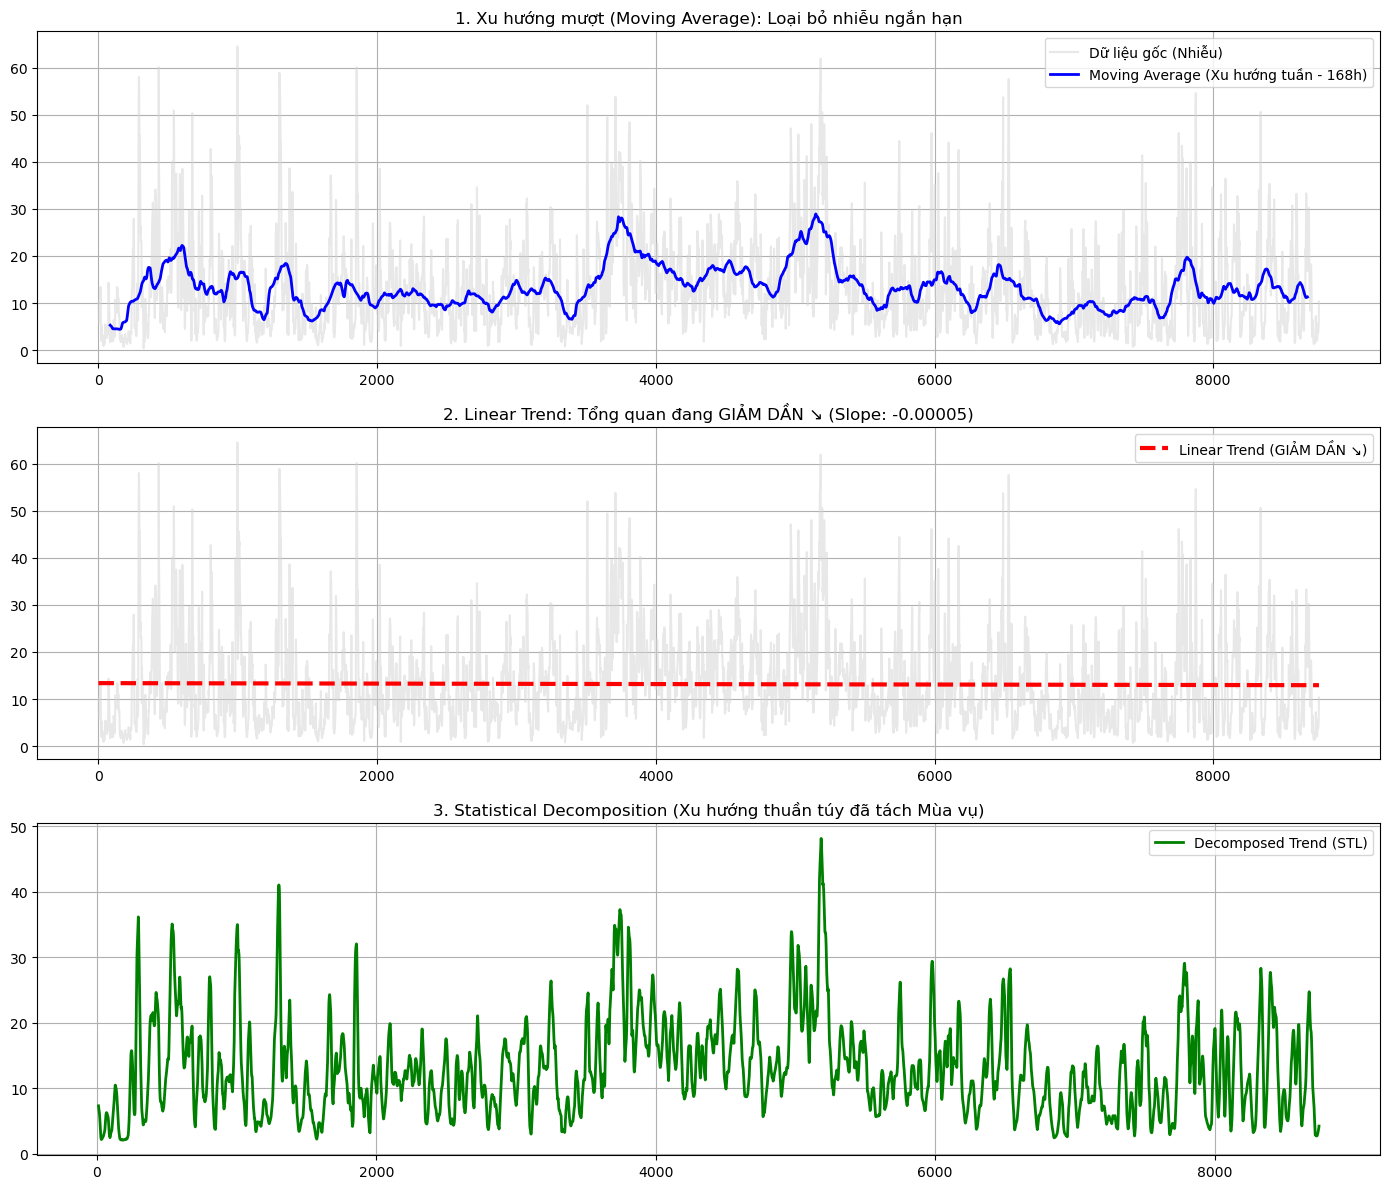

In [11]:


# ======================================================
# 1. CHUẨN BỊ DỮ LIỆU
# ======================================================
# Lấy cột PM2.5 từ dữ liệu gốc
ts_original = df['PM2.5'].dropna() # Bỏ các giá trị NaN để không bị lỗi vẽ hình

plt.figure(figsize=(14, 12))

# ======================================================
# CÁCH 1: MOVING AVERAGE (Trung bình trượt)
# ======================================================
# Mục tiêu: Làm "mượt" các gai nhọn để lộ ra xu hướng thật
# Window = 168: Lấy trung bình 7 ngày (24 giờ * 7) để loại bỏ biến động ngày thường/cuối tuần
ts_ma = ts_original.rolling(window=168, center=True).mean()

plt.subplot(3, 1, 1)
plt.plot(ts_original, color='lightgray', label='Dữ liệu gốc (Nhiễu)', alpha=0.5)
plt.plot(ts_ma, color='blue', linewidth=2, label='Moving Average (Xu hướng tuần - 168h)')
plt.title('1. Xu hướng mượt (Moving Average): Loại bỏ nhiễu ngắn hạn')
plt.legend()
plt.grid(True)

# ======================================================
# CÁCH 2: LINEAR REGRESSION (Xu hướng Tuyến tính)
# ======================================================
# Mục tiêu: Xác định hướng đi tổng quát (Tăng hay Giảm?)
# Tạo biến X (thời gian dạng số) và y (giá trị bụi)
X = np.arange(len(ts_original)).reshape(-1, 1)
y = ts_original.values.reshape(-1, 1)

# Chạy hồi quy
model = LinearRegression()
model.fit(X, y)
trend_line = model.predict(X)

# Kiểm tra hệ số góc (Slope)
slope = model.coef_[0][0]
trang_thai = "TĂNG DẦN ↗️" if slope > 0 else "GIẢM DẦN ↘️"

plt.subplot(3, 1, 2)
plt.plot(ts_original.index, ts_original, color='lightgray', alpha=0.5)
plt.plot(ts_original.index, trend_line, color='red', linewidth=3, linestyle='--', label=f'Linear Trend ({trang_thai})')
plt.title(f'2. Linear Trend: Tổng quan đang {trang_thai} (Slope: {slope:.5f})')
plt.legend()
plt.grid(True)

# ======================================================
# CÁCH 3: DECOMPOSITION (Phân rã chuỗi thời gian)
# ======================================================
# Mục tiêu: Tách dữ liệu thành 3 phần: Trend + Seasonality + Residual
# Period = 24: Chu kỳ ngày
result = seasonal_decompose(ts_original, model='additive', period=24)
ts_trend_decomp = result.trend

plt.subplot(3, 1, 3)
plt.plot(ts_trend_decomp, color='green', linewidth=2, label='Decomposed Trend (STL)')
plt.title('3. Statistical Decomposition (Xu hướng thuần túy đã tách Mùa vụ)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Kết quả sau khi tách ngày tháng:
                       Date  Hour  DayOfWeek    Month
0 2025-01-01 00:00:00+00:00     0  Wednesday  January
1 2025-01-01 01:00:00+00:00     1  Wednesday  January
2 2025-01-01 02:00:00+00:00     2  Wednesday  January
3 2025-01-01 03:00:00+00:00     3  Wednesday  January
4 2025-01-01 04:00:00+00:00     4  Wednesday  January


C:\Users\nguye\AppData\Local\Temp\ipykernel_50124\1461871229.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DayOfWeek', y='PM2.5', data=df, order=days_order, palette='viridis')
C:\Users\nguye\AppData\Local\Temp\ipykernel_50124\1461871229.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='PM2.5', data=df, order=available_months, palette='magma', errorbar=None)


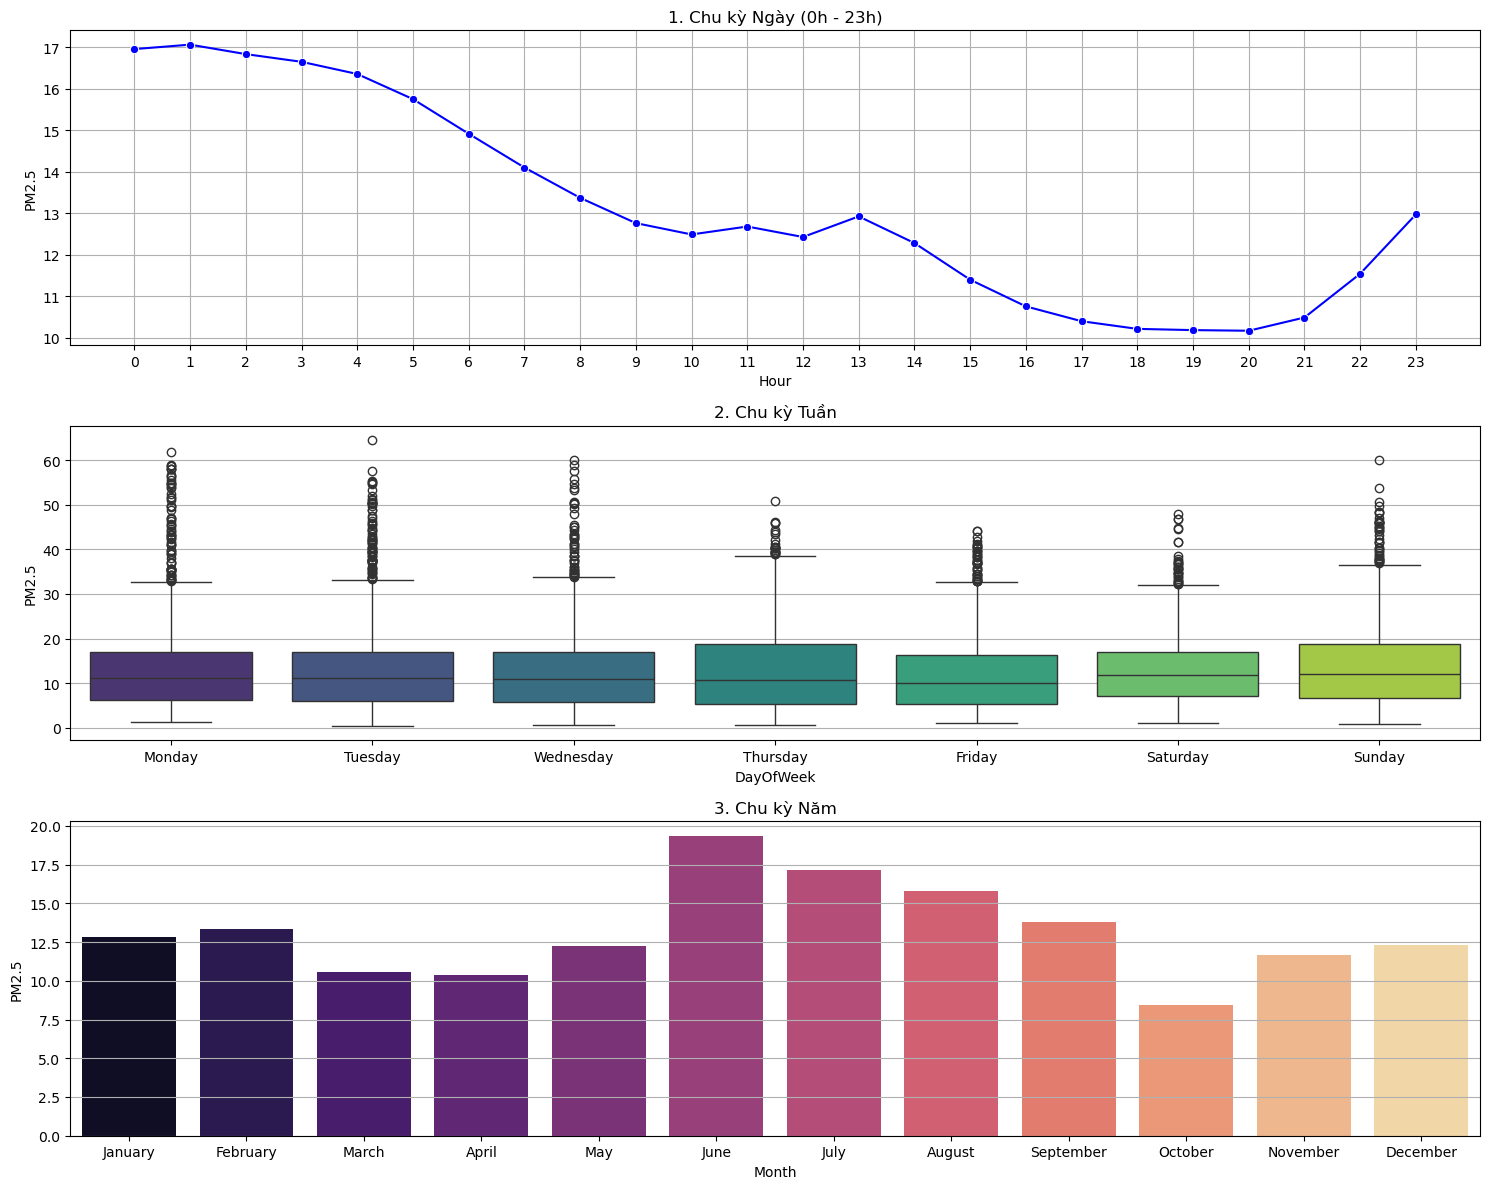

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================================
# 1. BƯỚC QUAN TRỌNG NHẤT: GIẢI MÃ CỘT DATE
# ======================================================
# Lệnh này sẽ biến chuỗi loằng ngoằng thành thời gian máy hiểu được
df['Date'] = pd.to_datetime(df['Date']) 

# Bây giờ ta có thể "móc" thông tin ra dễ dàng:
df['Hour'] = df['Date'].dt.hour           # Lấy giờ
df['DayOfWeek'] = df['Date'].dt.day_name() # Lấy thứ (Monday, Tuesday...)
df['Month'] = df['Date'].dt.month_name()   # Lấy tháng (January, February...)

# Kiểm tra thử xem nó ra gì (In ra 5 dòng đầu)
print("Kết quả sau khi tách ngày tháng:")
print(df[['Date', 'Hour', 'DayOfWeek', 'Month']].head())

# ======================================================
# 2. VẼ BIỂU ĐỒ (Phần này giữ nguyên)
# ======================================================
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(15, 12))

# A. Chu kỳ Ngày
plt.subplot(3, 1, 1)
sns.lineplot(x='Hour', y='PM2.5', data=df, marker='o', color='blue', errorbar=None)
plt.title('1. Chu kỳ Ngày (0h - 23h)')
plt.grid(True)
plt.xticks(range(0, 24))

# B. Chu kỳ Tuần
plt.subplot(3, 1, 2)
sns.boxplot(x='DayOfWeek', y='PM2.5', data=df, order=days_order, palette='viridis')
plt.title('2. Chu kỳ Tuần')
plt.grid(True, axis='y')

# C. Chu kỳ Năm
available_months = [m for m in months_order if m in df['Month'].unique()]
plt.subplot(3, 1, 3)
sns.barplot(x='Month', y='PM2.5', data=df, order=available_months, palette='magma', errorbar=None)
plt.title('3. Chu kỳ Năm')
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

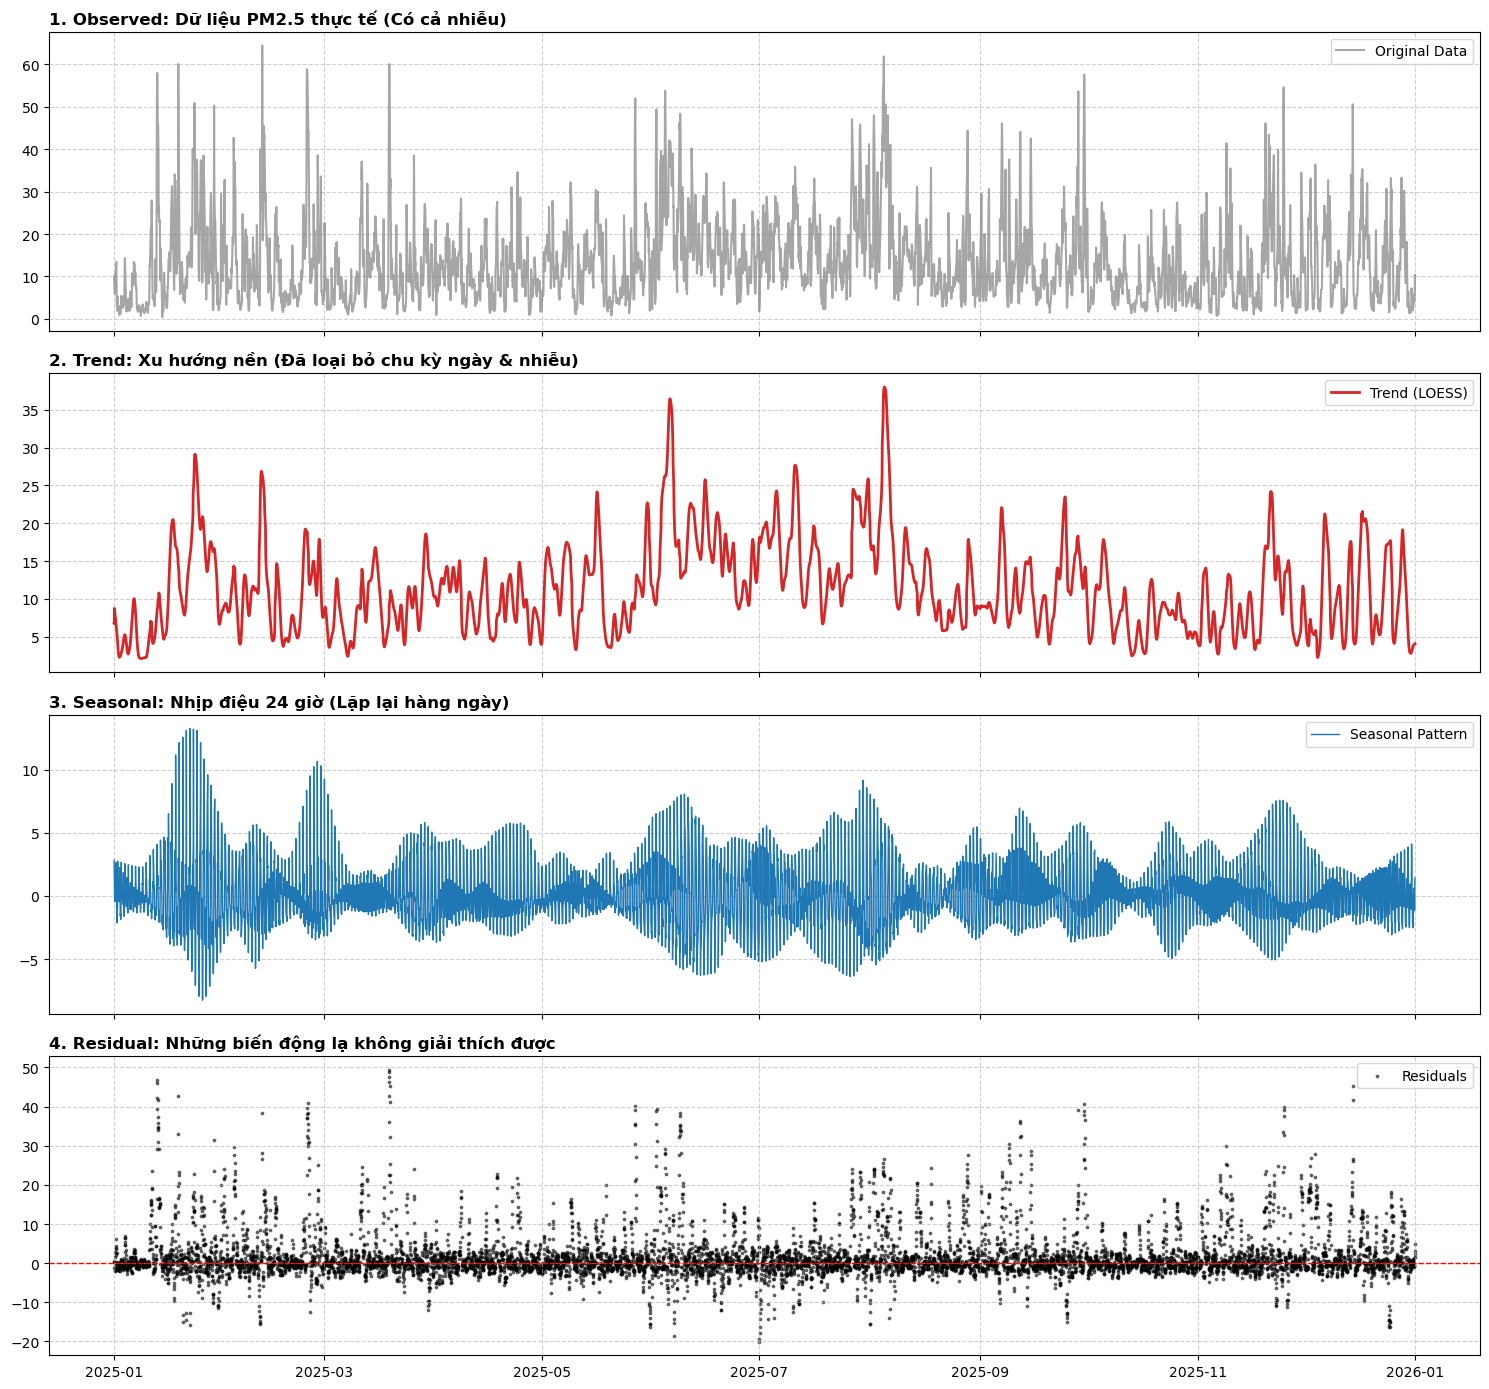

Phương sai Trend (Biến động dài hạn): 34.75
Phương sai Seasonal (Biến động hàng ngày): 5.61
Phương sai Residual (Độ nhiễu): 40.41
👉 KẾT LUẬN: Dữ liệu bị chi phối chủ yếu bởi xu hướng TĂNG/GIẢM dài hạn (Trend strong).


In [16]:


# ======================================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU ĐÚNG CHUẨN CHO STL
# ======================================================
# STL rất kỹ tính, nó yêu cầu Index phải là thời gian liên tục và có tần suất (Frequency)

# 1. Tạo bản sao và xử lý cột Date
df_stl = df.copy()
df_stl['Date'] = pd.to_datetime(df_stl['Date'])
df_stl.set_index('Date', inplace=True)

# 2. Thiết lập tần suất là 'H' (Hourly - Hàng giờ)
# Lệnh này sẽ điền các giờ bị thiếu (nếu có) bằng NaN để trục thời gian liền mạch
df_stl = df_stl.asfreq('h')

# 3. Xử lý dữ liệu thiếu (Interpolation)
# STL không chạy được nếu có NaN. Ta dùng nội suy tuyến tính để lấp đầy khoảng trống
df_stl['PM2.5'] = df_stl['PM2.5'].interpolate(method='linear')

# ======================================================
# BƯỚC 2: CHẠY THUẬT TOÁN STL DECOMPOSITION
# ======================================================
# period=24: Chu kỳ lặp lại là 24 giờ
# robust=True: BẬT chế độ kháng nhiễu (Rất quan trọng với dữ liệu bụi)
# seasonal=13: Độ mượt của mùa vụ (Số lẻ, thường để mặc định 7 hoặc 13)
stl_model = STL(df_stl['PM2.5'], period=24, robust=True, seasonal=13)
result = stl_model.fit()

# ======================================================
# BƯỚC 3: VẼ BIỂU ĐỒ PHÂN TÍCH CHUYÊN SÂU
# ======================================================
fig, axes = plt.subplots(4, 1, figsize=(15, 14), sharex=True)

# 1. Dữ liệu gốc (Observed)
axes[0].plot(result.observed, color='gray', alpha=0.7, label='Original Data')
axes[0].set_title('1. Observed: Dữ liệu PM2.5 thực tế (Có cả nhiễu)', loc='left', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Xu hướng (Trend) - Phần quan trọng nhất
axes[1].plot(result.trend, color='#d62728', linewidth=2, label='Trend (LOESS)')
axes[1].set_title('2. Trend: Xu hướng nền (Đã loại bỏ chu kỳ ngày & nhiễu)', loc='left', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Mùa vụ (Seasonal)
axes[2].plot(result.seasonal, color='#1f77b4', linewidth=1, label='Seasonal Pattern')
axes[2].set_title('3. Seasonal: Nhịp điệu 24 giờ (Lặp lại hàng ngày)', loc='left', fontsize=12, fontweight='bold')
axes[2].legend(loc='upper right')
axes[2].grid(True, linestyle='--', alpha=0.6)
# Zoom vào 1 tuần đầu tiên để thấy rõ sóng
# axes[2].set_xlim(df_stl.index[0], df_stl.index[168]) 

# 4. Phần dư (Residual)
axes[3].scatter(result.resid.index, result.resid, color='black', s=3, alpha=0.5, label='Residuals')
axes[3].axhline(0, color='red', linestyle='--', linewidth=1)
axes[3].set_title('4. Residual: Những biến động lạ không giải thích được', loc='left', fontsize=12, fontweight='bold')
axes[3].legend(loc='upper right')
axes[3].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ======================================================
# BƯỚC 4: ĐÁNH GIÁ SỨC MẠNH CỦA TREND VÀ SEASONAL
# ======================================================
# Tính toán xem Trend hay Seasonal đóng góp bao nhiêu % vào dữ liệu
var_trend = result.trend.var()
var_seasonal = result.seasonal.var()
var_resid = result.resid.var()

print(f"Phương sai Trend (Biến động dài hạn): {var_trend:.2f}")
print(f"Phương sai Seasonal (Biến động hàng ngày): {var_seasonal:.2f}")
print(f"Phương sai Residual (Độ nhiễu): {var_resid:.2f}")

if var_seasonal > var_trend:
    print("👉 KẾT LUẬN: Dữ liệu bị chi phối chủ yếu bởi chu kỳ NGÀY ĐÊM (Seasonal strong).")
else:
    print("👉 KẾT LUẬN: Dữ liệu bị chi phối chủ yếu bởi xu hướng TĂNG/GIẢM dài hạn (Trend strong).")

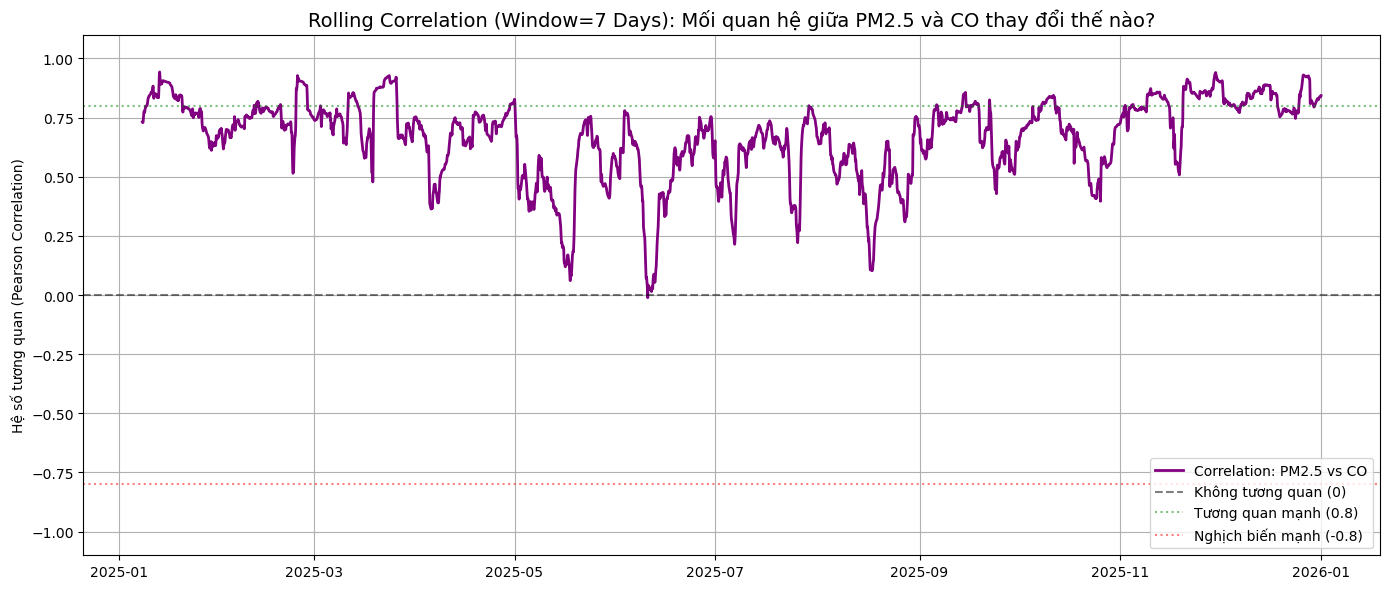

In [17]:
# Đảm bảo index là thời gian
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

# Chọn cặp đôi để "soi" mối quan hệ
# Bạn có thể đổi 'CO' thành 'NO2', 'SO2' hoặc 'PM10' để xem thử
target_var = 'PM2.5'
compare_var = 'CO'  # Carbon Monoxide (thường đại diện cho xe cộ/đốt cháy)

# ======================================================
# 2. TÍNH ROLLING CORRELATION
# ======================================================
# window=168: Cửa sổ trượt 7 ngày (24 giờ * 7 ngày)
# Nghĩa là: Tại mỗi giờ, nó nhìn lại 1 tuần trước đó để tính độ tương quan
rolling_corr = df[target_var].rolling(window=168).corr(df[compare_var])

# ======================================================
# 3. VẼ BIỂU ĐỒ
# ======================================================
plt.figure(figsize=(14, 6))

# Vẽ đường tương quan
plt.plot(rolling_corr, color='purple', linewidth=2, label=f'Correlation: {target_var} vs {compare_var}')

# Vẽ đường kẻ ngang tham chiếu
plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Không tương quan (0)')
plt.axhline(0.8, color='green', linestyle=':', alpha=0.5, label='Tương quan mạnh (0.8)')
plt.axhline(-0.8, color='red', linestyle=':', alpha=0.5, label='Nghịch biến mạnh (-0.8)')

plt.title(f'Rolling Correlation (Window=7 Days): Mối quan hệ giữa {target_var} và {compare_var} thay đổi thế nào?', fontsize=14)
plt.ylabel('Hệ số tương quan (Pearson Correlation)')
plt.legend(loc='lower right')
plt.grid(True)
plt.ylim(-1.1, 1.1) # Giới hạn trục Y từ -1 đến 1

plt.tight_layout()
plt.show()

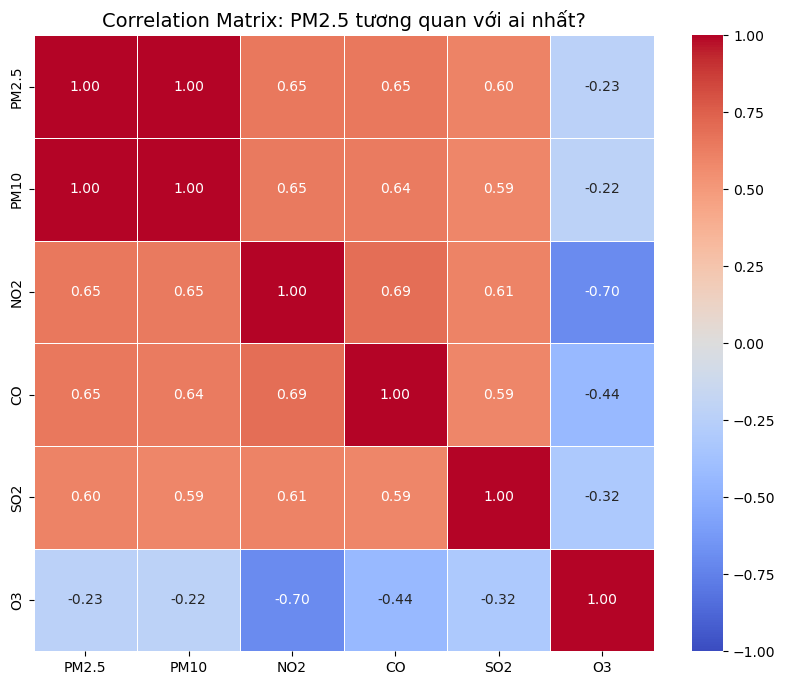

--- BẢNG XẾP HẠNG ĐỘ TƯƠNG QUAN VỚI PM2.5 ---
PM10    0.996310
NO2     0.650047
CO      0.649921
SO2     0.602917
O3     -0.228161
Name: PM2.5, dtype: float64


In [18]:
# ======================================================
# 1. TÍNH TOÁN MA TRẬN TƯƠNG QUAN
# ======================================================
# Chọn các cột chất ô nhiễm cần so sánh
cols_to_check = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']

# Tính hệ số tương quan (Pearson Correlation)
corr_matrix = df[cols_to_check].corr()

# ======================================================
# 2. VẼ HEATMAP (BẢN ĐỒ NHIỆT) ĐỂ DỄ NHÌN
# ======================================================
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix: PM2.5 tương quan với ai nhất?', fontsize=14)
plt.show()

# ======================================================
# 3. IN RA BẢNG XẾP HẠNG CỤ THỂ CHO PM2.5
# ======================================================
print("--- BẢNG XẾP HẠNG ĐỘ TƯƠNG QUAN VỚI PM2.5 ---")
# Lấy cột PM2.5, sắp xếp giảm dần và bỏ đi chính nó
ranking = corr_matrix['PM2.5'].drop('PM2.5').sort_values(ascending=False)
print(ranking)